# Chương 4. HỌC MÁY

### Thuật toán OPSTIC
DBSCAN xác định cụm dựa trên mật độ dữ liệu, nhưng độ dày đặc của các điểm không phải lúc nào cũng đồng đều. Với các tập dữ liệu có mật độ khác nhau, một bán kính $\epsilon$ cố định sẽ không còn phù hợp: vùng thưa cần $\epsilon$ lớn hơn, trong khi vùng dày cần $\epsilon$ nhỏ hơn. Nhu cầu linh hoạt này chính là ý tưởng dẫn đến thuật toán OPTICS (Ordering Points To Identify the Clustering Structure), phiên bản cải tiến của DBSCAN. OPTICS được xây dựng dựa trên hai tham số bao gồm $\epsilon$ và minPts. Ngoài ra, thuật toán OPSTIC có định nghĩa thêm hai khái niệm khoảng cách:

**• Khoảng cách trung tâm (core distance)**  
Là khoảng cách từ điểm trung tâm đến điểm gần nhất thứ **minPts** trong vùng lân cận $\epsilon$. Lưu ý: chỉ xác định cho **core point**.

$$
\mathrm{CoreDistance}(p) = \text{Distance}\big(p,\; \text{MinPts-th nearest neighbor within } \varepsilon \big)
$$

 **• Khoảng cách tiếp cận (reachability distance)**  
Là khoảng cách nhỏ nhất từ một điểm trung tâm $p$ đến một điểm bất kỳ $o$. Nếu $p$ **không** phải là core point thì khoảng cách tiếp cận **không được xác định**.  
Khi $p$ là core point, khoảng cách tiếp cận được định nghĩa như sau:

$$
\mathrm{ReachabilityDistance}(o, p)
=
\max\left(\mathrm{CoreDistance}(p),\; \mathrm{distance}(p, o)\right)
$$

<p align="center">
  <img src="../picture/OPSTIC.drawio.png" width="400">
  <br>
  <em>Hình 1. Khoảng cách trung tâm (CoreDistance) và khoảng cách với (ReachabilityDistance) trong OPSTIC.</em>
</p>




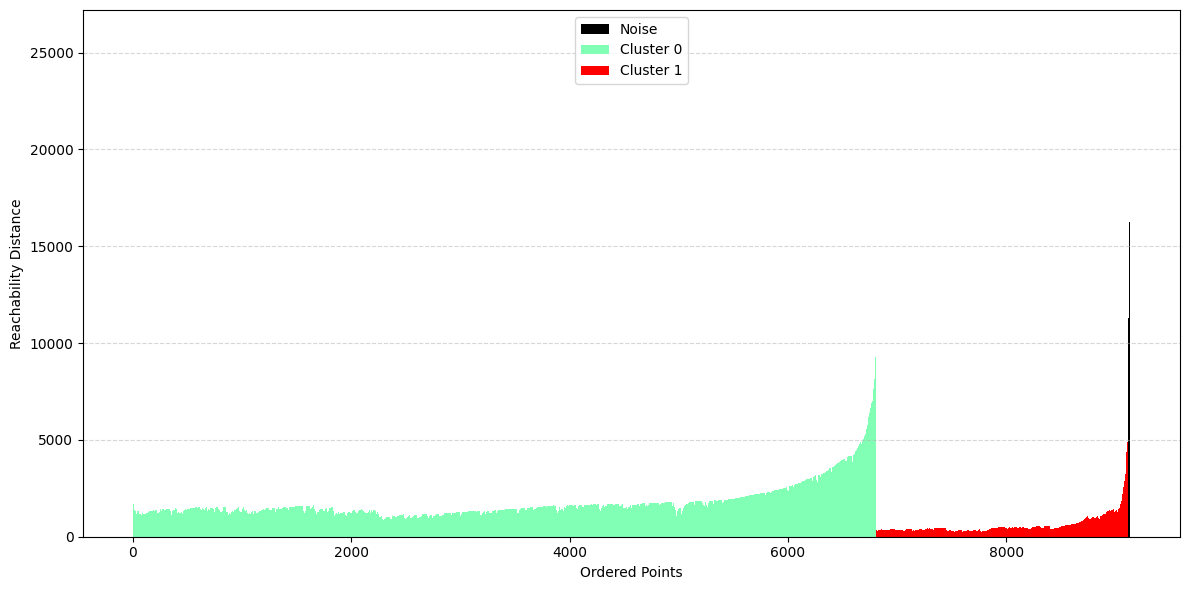

In [6]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import OPTICS
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Nhập dữ liệu
cus = pd.read_csv('../data/customer.csv')
cus_numeric = cus.select_dtypes(include=['int', 'float'])
cus_clean = cus_numeric.dropna(axis=1)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cus_clean)

pca = PCA(n_components=5) 
X_pca = pca.fit_transform(cus_clean)

# OPSTIC
optics = OPTICS(min_samples=15, xi=0.03, min_cluster_size=0.03)
optics.fit(X_pca)

labels = optics.labels_ 
reachability = optics.reachability_[optics.ordering_]
labels_ordered = optics.labels_[optics.ordering_]

# Trực quan
plt.figure(figsize=(12, 6))
colors = plt.cm.rainbow(np.linspace(0, 1, len(set(labels))))

for klass, color in zip(sorted(set(labels)), colors):
    label = f'Cluster {klass}' if klass != -1 else 'Noise'
    color = 'k' if klass == -1 else color

    Xk = np.where(labels_ordered == klass)[0]
    plt.bar(Xk, reachability[Xk], color=color, label=label, width=1.0)

plt.xlabel('Ordered Points')
plt.ylabel('Reachability Distance')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

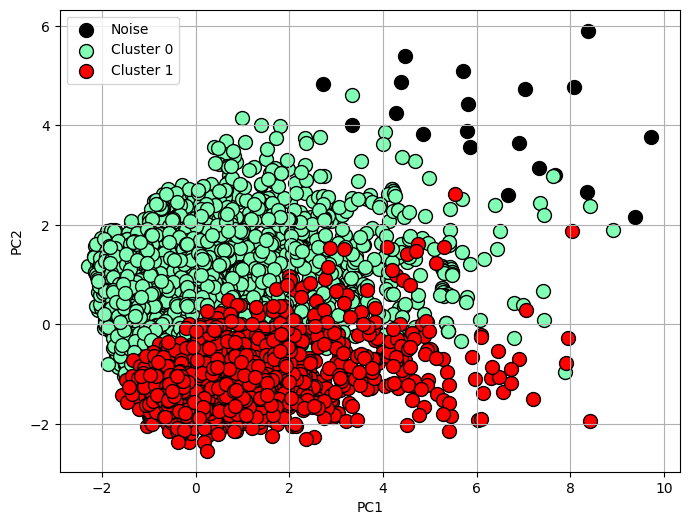

In [9]:
plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
# Giảm chiều dữ liệu về 2D để trực quan bằng PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)
for label, color in zip(sorted(unique_labels), colors):
    label_name = f'Cluster {label}' if label != -1 else 'Noise'
    color = 'k' if label == -1 else color
    plt.scatter(X_pca[labels == label, 0], X_pca[labels == label, 1],
    edgecolors='black', linewidths=1.0, c=[color], label=label_name, s=100)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()
